In [1]:
# Import the required data analysis libraries
import pandas as pd
import numpy as np

# Load a single ball-by-ball CSV file into a Pandas DataFrame
df = pd.read_csv('335982.csv')

# Display the first 5 rows to ensure it loaded correctly
df.head()

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2007/08,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,...,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2007/08,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2007/08,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2007/08,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2007/08,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# 1. Get a summary of all columns and their data types
df.info()

# 2. Count exactly how many blank/missing values exist in every single column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   match_id                225 non-null    int64  
 1   season                  225 non-null    object 
 2   start_date              225 non-null    object 
 3   venue                   225 non-null    object 
 4   innings                 225 non-null    int64  
 5   ball                    225 non-null    float64
 6   batting_team            225 non-null    object 
 7   bowling_team            225 non-null    object 
 8   striker                 225 non-null    object 
 9   non_striker             225 non-null    object 
 10  bowler                  225 non-null    object 
 11  runs_off_bat            225 non-null    int64  
 12  extras                  225 non-null    int64  
 13  wides                   14 non-null     float64
 14  noballs                 0 non-null      fl

match_id                    0
season                      0
start_date                  0
venue                       0
innings                     0
ball                        0
batting_team                0
bowling_team                0
striker                     0
non_striker                 0
bowler                      0
runs_off_bat                0
extras                      0
wides                     211
noballs                   225
byes                      224
legbyes                   216
penalty                   225
wicket_type               212
player_dismissed          212
other_wicket_type         225
other_player_dismissed    225
dtype: int64

In [3]:
# 1. Replace blanks in the "runs/extras" columns with the number 0
extra_columns = ['wides', 'noballs', 'byes', 'legbyes', 'penalty']
df[extra_columns] = df[extra_columns].fillna(0)

# 2. Replace blanks in the "wickets" columns with the text 'No Wicket'
wicket_columns = ['wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed']
df[wicket_columns] = df[wicket_columns].fillna('No Wicket')

# 3. Check our missing values one more time to make sure it worked
df.isnull().sum()

match_id                  0
season                    0
start_date                0
venue                     0
innings                   0
ball                      0
batting_team              0
bowling_team              0
striker                   0
non_striker               0
bowler                    0
runs_off_bat              0
extras                    0
wides                     0
noballs                   0
byes                      0
legbyes                   0
penalty                   0
wicket_type               0
player_dismissed          0
other_wicket_type         0
other_player_dismissed    0
dtype: int64

In [4]:
# 1. Create a list of columns that do not impact the core win probability
useless_columns = [
    'match_id', 
    'season', 
    'start_date', 
    'striker', 
    'non_striker', 
    'bowler', 
    'other_wicket_type', 
    'other_player_dismissed'
]

# 2. Drop these columns from our dataframe (axis=1 tells Pandas to drop columns, not rows)
df = df.drop(useless_columns, axis=1)

# 3. Print the new shape of the dataset to confirm they are gone
print("Data cleaning successful. Remaining rows and columns:")
print(df.shape)

Data cleaning successful. Remaining rows and columns:
(225, 14)


In [5]:
# 1. Calculate the total runs scored on each specific delivery
df['total_runs_on_ball'] = df['runs_off_bat'] + df['extras']

# 2. Calculate the cumulative running score for each innings
df['current_score'] = df.groupby('innings')['total_runs_on_ball'].cumsum()

# 3. Calculate wickets in hand
# First, tell Python to flag a '1' if a wicket fell, and a '0' if it didn't
df['wicket_fell'] = np.where(df['player_dismissed'] != 'No Wicket', 1, 0)

# Next, keep a running tally of wickets lost per innings
df['wickets_lost'] = df.groupby('innings')['wicket_fell'].cumsum()

# Finally, subtract the lost wickets from 10 to get the wickets in hand
df['wickets_in_hand'] = 10 - df['wickets_lost']

# 4. Preview the last 10 balls of the match to see our new features in action!
df[['innings', 'ball', 'current_score', 'wickets_in_hand']].tail(10)

,innings,ball,current_score,wickets_in_hand
215,2,13.6,77,1
216,2,14.1,78,1
217,2,14.2,78,1
218,2,14.3,78,1
219,2,14.4,79,1
220,2,14.5,80,1
221,2,14.6,81,1
222,2,14.7,81,1
223,2,15.1,82,1
224,2,15.2,82,0


In [6]:
# Save the cleaned dataset to your Dissertation_Data folder
# Setting index=False prevents Pandas from exporting the row numbers as a new column
df.to_csv('Cleaned_Match_Data.csv', index=False)

print("Phase 1 Complete: Clean dataset saved successfully!")

Phase 1 Complete: Clean dataset saved successfully!


In [7]:
import numpy as np

# 1. CALCULATING BALLS BOWLED & BALLS REMAINING
# Cricsheet format is "0.1" (0 completed overs, 1 ball). 
# We multiply the completed overs by 6, then add the decimal part.
df['over'] = df['ball'].astype(int)
df['ball_no'] = (df['ball'] * 10 % 10).round().astype(int)
df['balls_bowled'] = (df['over'] * 6) + df['ball_no']

# T20 innings have a maximum of 120 legal deliveries
df['balls_remaining'] = 120 - df['balls_bowled']
# Prevent negative balls remaining in case of extras/super overs
df['balls_remaining'] = df['balls_remaining'].apply(lambda x: 0 if x < 0 else x)


# 2. CHASING METRICS (Target and Runs Required)
# Calculate the total score of Innings 1 and add 1 run
innings_1_total = df[df['innings'] == 1]['total_runs_on_ball'].sum()
target_score = innings_1_total + 1

# Apply target score ONLY to the 2nd Innings
df['target_score'] = np.where(df['innings'] == 2, target_score, np.nan)
df['runs_required'] = np.where(df['innings'] == 2, df['target_score'] - df['current_score'], np.nan)


# 3. RUN RATES (Pressure Gauge)
# Current Run Rate (CRR) = (Current Score / Balls Bowled) * 6
df['crr'] = (df['current_score'] * 6) / df['balls_bowled']

# Required Run Rate (RRR) = (Runs Required / Balls Remaining) * 6
# We use np.where to avoid division by zero errors on the final ball
df['rrr'] = np.where(
    (df['innings'] == 2) & (df['balls_remaining'] > 0), 
    (df['runs_required'] * 6) / df['balls_remaining'], 
    np.nan
)


# 4. MATCH MOMENTUM (Rolling 5 Overs)
# We use a 'rolling window' of 30 balls to look back at the immediate past
df['runs_last_5_overs'] = df.groupby('innings')['total_runs_on_ball'].rolling(window=30, min_periods=1).sum().reset_index(0, drop=True)
df['wickets_last_5_overs'] = df.groupby('innings')['wicket_fell'].rolling(window=30, min_periods=1).sum().reset_index(0, drop=True)


# 5. DROP TEMPORARY CALCULATION COLUMNS
df = df.drop(columns=['over', 'ball_no'])

# Preview the engineered dataset for the 2nd Innings (where all features are active)
print(f"Shape after advanced feature engineering: {df.shape}")
df[df['innings'] == 2][['ball', 'current_score', 'runs_required', 'crr', 'rrr', 'runs_last_5_overs', 'wickets_last_5_overs']].head(10)

Shape after advanced feature engineering: (225, 27)


,ball,current_score,runs_required,crr,rrr,runs_last_5_overs,wickets_last_5_overs
124,0.1,1,222.0,6.000000,11.193277,1.0,0.0
125,0.2,2,221.0,6.000000,11.237288,2.0,0.0
126,0.3,2,221.0,4.000000,11.333333,2.0,0.0
127,0.4,3,220.0,4.500000,11.379310,3.0,0.0
128,0.5,4,219.0,4.800000,11.426087,4.0,0.0
129,0.6,4,219.0,4.000000,11.526316,4.0,0.0
130,0.7,4,219.0,3.428571,11.628319,4.0,0.0
131,1.1,4,219.0,3.428571,11.628319,4.0,1.0
132,1.2,4,219.0,3.000000,11.732143,4.0,1.0
133,1.3,8,215.0,5.333333,11.621622,8.0,1.0


In [8]:
import pandas as pd
import numpy as np
import os

# 1. Define where your files live on your Mac
folder_path = 'ipl_male_csv2' 

# Create an empty list to hold every cleaned match
all_cleaned_matches = []

print("Starting the Master Data Pipeline... This might take a minute!")

# 2. Start the loop through your folder
for filename in os.listdir(folder_path):

    # Only process ball-by-ball CSV files and completely ignore the _info files
    if filename.endswith('.csv') and '_info' not in filename:
        
        file_path = os.path.join(folder_path, filename)
        
        # Load the raw match
        df = pd.read_csv(file_path)
        
        # --- PHASE 1: CLEANING ---
        # Fill missing extras
        extra_cols = ['wides', 'noballs', 'byes', 'legbyes', 'penalty']
        df[extra_cols] = df[extra_cols].fillna(0)
        
        # Fill missing wickets
        wicket_cols = ['wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed']
        df[wicket_cols] = df[wicket_cols].fillna('No Wicket')
        
        # Drop useless columns (using errors='ignore' for older files)
        useless = ['match_id', 'season', 'start_date', 'striker', 'non_striker', 'bowler', 'other_wicket_type', 'other_player_dismissed']
        df = df.drop(columns=useless, errors='ignore')
        
        # --- PHASE 2: FEATURE ENGINEERING ---
        # Basic momentum
        df['total_runs_on_ball'] = df['runs_off_bat'] + df['extras']
        df['current_score'] = df.groupby('innings')['total_runs_on_ball'].cumsum()
        df['wicket_fell'] = np.where(df['player_dismissed'] != 'No Wicket', 1, 0)
        df['wickets_lost'] = df.groupby('innings')['wicket_fell'].cumsum()
        df['wickets_in_hand'] = 10 - df['wickets_lost']
        
        # Balls remaining
        df['over'] = df['ball'].astype(int)
        df['ball_no'] = (df['ball'] * 10 % 10).round().astype(int)
        df['balls_bowled'] = (df['over'] * 6) + df['ball_no']
        df['balls_remaining'] = 120 - df['balls_bowled']
        df['balls_remaining'] = df['balls_remaining'].apply(lambda x: 0 if x < 0 else x)
        
        # Target score and chasing metrics
        innings_1_total = df[df['innings'] == 1]['total_runs_on_ball'].sum()
        df['target_score'] = np.where(df['innings'] == 2, innings_1_total + 1, np.nan)
        df['runs_required'] = np.where(df['innings'] == 2, df['target_score'] - df['current_score'], np.nan)
        
        # Run rates
        df['crr'] = (df['current_score'] * 6) / df['balls_bowled']
        df['rrr'] = np.where((df['innings'] == 2) & (df['balls_remaining'] > 0), (df['runs_required'] * 6) / df['balls_remaining'], np.nan)
        
        # Rolling momentum (Last 5 Overs / 30 balls)
        df['runs_last_5_overs'] = df.groupby('innings')['total_runs_on_ball'].rolling(window=30, min_periods=1).sum().reset_index(0, drop=True)
        df['wickets_last_5_overs'] = df.groupby('innings')['wicket_fell'].rolling(window=30, min_periods=1).sum().reset_index(0, drop=True)
        
        # --- PHASE 3: STRICT COLUMN SELECTION ---
        # Define the exact columns your machine learning model needs to survive
        final_columns = [
            'venue', 'innings', 'batting_team', 'bowling_team', 
            'current_score', 'wickets_in_hand', 'balls_remaining', 
            'target_score', 'runs_required', 'crr', 'rrr', 
            'runs_last_5_overs', 'wickets_last_5_overs'
        ]
        
        # Filter the dataframe to ONLY keep these columns and drop any weird new ones
        df_final = df[df.columns.intersection(final_columns)]
        
        # Add the fully processed match to our master list
        all_cleaned_matches.append(df_final)

# 4. Combine every single match into one massive table
print("Combining all matches into the master dataset...")
master_df = pd.concat(all_cleaned_matches, ignore_index=True)

# 5. Save the final master dataset to your folder
master_df.to_csv('Master_IPL_Dataset.csv', index=False)

print(f"Master pipeline complete! Total deliveries processed: {master_df.shape[0]}")

Starting the Master Data Pipeline... This might take a minute!


FileNotFoundError: [Errno 2] No such file or directory: 'ipl_male_csv2'

In [9]:
import pandas as pd
import numpy as np
import os

# 1. Define where your files live on your Mac
folder_path = 'ipl_male_csv2' 

# Create an empty list to hold every cleaned match
all_cleaned_matches = []

print("Starting the Master Data Pipeline... This might take a minute!")

# 2. Start the loop through your folder
for filename in os.listdir(folder_path):

    # Extract just the name before the '.csv' (e.g., '335982' from '335982.csv')
    file_prefix = filename.split('.')[0]

    # ONLY process if it's a CSV, NOT an info file, AND the name is strictly numbers
    if filename.endswith('.csv') and '_info' not in filename and file_prefix.isdigit():
        
        file_path = os.path.join(folder_path, filename)
        
        # Load the raw match
        df = pd.read_csv(file_path)
        
        # --- PHASE 1: CLEANING ---
        # Fill missing extras
        extra_cols = ['wides', 'noballs', 'byes', 'legbyes', 'penalty']
        df[extra_cols] = df[extra_cols].fillna(0)
        
        # Fill missing wickets
        wicket_cols = ['wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed']
        df[wicket_cols] = df[wicket_cols].fillna('No Wicket')
        
        # Drop useless columns (using errors='ignore' for older files)
        useless = ['match_id', 'season', 'start_date', 'striker', 'non_striker', 'bowler', 'other_wicket_type', 'other_player_dismissed']
        df = df.drop(columns=useless, errors='ignore')
        
        # --- PHASE 2: FEATURE ENGINEERING ---
        # Basic momentum
        df['total_runs_on_ball'] = df['runs_off_bat'] + df['extras']
        df['current_score'] = df.groupby('innings')['total_runs_on_ball'].cumsum()
        df['wicket_fell'] = np.where(df['player_dismissed'] != 'No Wicket', 1, 0)
        df['wickets_lost'] = df.groupby('innings')['wicket_fell'].cumsum()
        df['wickets_in_hand'] = 10 - df['wickets_lost']
        
        # Balls remaining
        df['over'] = df['ball'].astype(int)
        df['ball_no'] = (df['ball'] * 10 % 10).round().astype(int)
        df['balls_bowled'] = (df['over'] * 6) + df['ball_no']
        df['balls_remaining'] = 120 - df['balls_bowled']
        df['balls_remaining'] = df['balls_remaining'].apply(lambda x: 0 if x < 0 else x)
        
        # Target score and chasing metrics
        innings_1_total = df[df['innings'] == 1]['total_runs_on_ball'].sum()
        df['target_score'] = np.where(df['innings'] == 2, innings_1_total + 1, np.nan)
        df['runs_required'] = np.where(df['innings'] == 2, df['target_score'] - df['current_score'], np.nan)
        
        # Run rates
        df['crr'] = (df['current_score'] * 6) / df['balls_bowled']
        df['rrr'] = np.where((df['innings'] == 2) & (df['balls_remaining'] > 0), (df['runs_required'] * 6) / df['balls_remaining'], np.nan)
        
        # Rolling momentum (Last 5 Overs / 30 balls)
        df['runs_last_5_overs'] = df.groupby('innings')['total_runs_on_ball'].rolling(window=30, min_periods=1).sum().reset_index(0, drop=True)
        df['wickets_last_5_overs'] = df.groupby('innings')['wicket_fell'].rolling(window=30, min_periods=1).sum().reset_index(0, drop=True)
        
        # --- PHASE 3: STRICT COLUMN SELECTION ---
        # Define the exact columns your machine learning model needs to survive
        final_columns = [
            'venue', 'innings', 'batting_team', 'bowling_team', 
            'current_score', 'wickets_in_hand', 'balls_remaining', 
            'target_score', 'runs_required', 'crr', 'rrr', 
            'runs_last_5_overs', 'wickets_last_5_overs'
        ]
        
        # Filter the dataframe to ONLY keep these columns and drop any weird new ones
        df_final = df[df.columns.intersection(final_columns)]
        
        # Add the fully processed match to our master list
        all_cleaned_matches.append(df_final)

# 4. Combine every single match into one massive table
print("Combining all matches into the master dataset...")
master_df = pd.concat(all_cleaned_matches, ignore_index=True)

# 5. Save the final master dataset to your folder
master_df.to_csv('Master_IPL_Dataset.csv', index=False)

print(f"Master pipeline complete! Total deliveries processed: {master_df.shape[0]}")

Starting the Master Data Pipeline... This might take a minute!


FileNotFoundError: [Errno 2] No such file or directory: 'ipl_male_csv2'

In [10]:
import pandas as pd
import numpy as np
import os

# 1. Look in the CURRENT folder (since your notebook is already here)
folder_path = '.' 

# Create an empty list to hold every cleaned match
all_cleaned_matches = []

print("Starting the Master Data Pipeline... This might take a minute!")

# 2. Start the loop through your folder
for filename in os.listdir(folder_path):

    # Extract just the name before the '.csv' (e.g., '335982' from '335982.csv')
    file_prefix = filename.split('.')[0]

    # ONLY process if it's a CSV, NOT an info file, AND the name is strictly numbers
    if filename.endswith('.csv') and '_info' not in filename and file_prefix.isdigit():
        
        file_path = os.path.join(folder_path, filename)
        
        # Load the raw match
        df = pd.read_csv(file_path)
        
        # --- PHASE 1: CLEANING ---
        # Fill missing extras
        extra_cols = ['wides', 'noballs', 'byes', 'legbyes', 'penalty']
        df[extra_cols] = df[extra_cols].fillna(0)
        
        # Fill missing wickets
        wicket_cols = ['wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed']
        df[wicket_cols] = df[wicket_cols].fillna('No Wicket')
        
        # Drop useless columns (using errors='ignore' for older files)
        useless = ['match_id', 'season', 'start_date', 'striker', 'non_striker', 'bowler', 'other_wicket_type', 'other_player_dismissed']
        df = df.drop(columns=useless, errors='ignore')
        
        # --- PHASE 2: FEATURE ENGINEERING ---
        # Basic momentum
        df['total_runs_on_ball'] = df['runs_off_bat'] + df['extras']
        df['current_score'] = df.groupby('innings')['total_runs_on_ball'].cumsum()
        df['wicket_fell'] = np.where(df['player_dismissed'] != 'No Wicket', 1, 0)
        df['wickets_lost'] = df.groupby('innings')['wicket_fell'].cumsum()
        df['wickets_in_hand'] = 10 - df['wickets_lost']
        
        # Balls remaining
        df['over'] = df['ball'].astype(int)
        df['ball_no'] = (df['ball'] * 10 % 10).round().astype(int)
        df['balls_bowled'] = (df['over'] * 6) + df['ball_no']
        df['balls_remaining'] = 120 - df['balls_bowled']
        df['balls_remaining'] = df['balls_remaining'].apply(lambda x: 0 if x < 0 else x)
        
        # Target score and chasing metrics
        innings_1_total = df[df['innings'] == 1]['total_runs_on_ball'].sum()
        df['target_score'] = np.where(df['innings'] == 2, innings_1_total + 1, np.nan)
        df['runs_required'] = np.where(df['innings'] == 2, df['target_score'] - df['current_score'], np.nan)
        
        # Run rates
        df['crr'] = (df['current_score'] * 6) / df['balls_bowled']
        df['rrr'] = np.where((df['innings'] == 2) & (df['balls_remaining'] > 0), (df['runs_required'] * 6) / df['balls_remaining'], np.nan)
        
        # Rolling momentum (Last 5 Overs / 30 balls)
        df['runs_last_5_overs'] = df.groupby('innings')['total_runs_on_ball'].rolling(window=30, min_periods=1).sum().reset_index(0, drop=True)
        df['wickets_last_5_overs'] = df.groupby('innings')['wicket_fell'].rolling(window=30, min_periods=1).sum().reset_index(0, drop=True)
        
        # --- PHASE 3: STRICT COLUMN SELECTION ---
        # Define the exact columns your machine learning model needs to survive
        final_columns = [
            'venue', 'innings', 'batting_team', 'bowling_team', 
            'current_score', 'wickets_in_hand', 'balls_remaining', 
            'target_score', 'runs_required', 'crr', 'rrr', 
            'runs_last_5_overs', 'wickets_last_5_overs'
        ]
        
        # Filter the dataframe to ONLY keep these columns and drop any weird new ones
        df_final = df[df.columns.intersection(final_columns)]
        
        # Add the fully processed match to our master list
        all_cleaned_matches.append(df_final)

# 4. Combine every single match into one massive table
print("Combining all matches into the master dataset...")
master_df = pd.concat(all_cleaned_matches, ignore_index=True)

# 5. Save the final master dataset to your folder
master_df.to_csv('Master_IPL_Dataset.csv', index=False)

print(f"Master pipeline complete! Total deliveries processed: {master_df.shape[0]}")

Starting the Master Data Pipeline... This might take a minute!
Combining all matches into the master dataset...
Master pipeline complete! Total deliveries processed: 295732


In [11]:
import pandas as pd

print("Loading the Master Dataset...")
# Load the master dataset we just built
df = pd.read_csv('Master_IPL_Dataset.csv')

# 1. HANDLE THE FIRST INNINGS NaNs
# Replace blanks in the chasing columns with 0, since Innings 1 has no target or required run rate
chasing_columns = ['target_score', 'runs_required', 'rrr']
df[chasing_columns] = df[chasing_columns].fillna(0)

# 2. STANDARDIZE TEAM NAMES (Crucial for older data)
# IPL teams occasionally change names (e.g., Delhi Daredevils -> Delhi Capitals)
# We map old names to current names so the computer knows they are the same franchise
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings',
    'Gujarat Lions': 'Gujarat Titans',
    'Rising Pune Supergiant': 'Rising Pune Supergiants', # Fix slight spelling variations
    'Pune Warriors': 'Rising Pune Supergiants'
}
df['batting_team'] = df['batting_team'].replace(team_mapping)
df['bowling_team'] = df['bowling_team'].replace(team_mapping)

# 3. ONE-HOT ENCODING
print("Translating text to machine-readable numbers...")
# Convert categorical text columns into binary columns (1s and 0s)
# drop_first=True helps prevent "multicollinearity" which confuses Logistic Regression
categorical_columns = ['batting_team', 'bowling_team', 'venue']
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

print(f"Old Shape (Text): {df.shape}")
print(f"New Shape (Encoded): {df_encoded.shape}")

# Save this ultimate, model-ready dataset!
df_encoded.to_csv('Model_Ready_IPL_Data.csv', index=False)
print("Data is officially ready for Machine Learning!")

Loading the Master Dataset...
Translating text to machine-readable numbers...
Old Shape (Text): (295732, 13)
New Shape (Encoded): (295732, 93)
Data is officially ready for Machine Learning!


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

print("Loading the encoded dataset...")
# Load the model-ready data we just saved
df = pd.read_csv('Model_Ready_IPL_Data.csv')

# --- STEP 1: DEFINING THE TARGET (y) ---

# 1a. Recreate match boundaries (A new match starts when innings resets to 1)
df['match_id'] = ((df['innings'] == 1) & (df['innings'].shift(1) != 1)).cumsum()

# 1b. Look at the very last ball of every single match
final_balls = df.drop_duplicates(subset=['match_id'], keep='last')

# 1c. Did the chasing team (Innings 2) win? (1 for Yes, 0 for No)
chasing_wins = (final_balls['innings'] == 2) & (final_balls['current_score'] >= final_balls['target_score'])
match_winner_dict = dict(zip(final_balls['match_id'], chasing_wins.astype(int)))

# 1d. Map the winner back to every single ball in the dataset
df['chasing_team_won'] = df['match_id'].map(match_winner_dict)

# 1e. Create our final Target Variable (y): "Did the current batting team win?"
df['target'] = np.where(df['innings'] == 2, df['chasing_team_won'], 1 - df['chasing_team_won'])

# Drop the temporary calculation columns
df = df.drop(columns=['match_id', 'chasing_team_won'])

# --- STEP 2: THE TRAIN-TEST SPLIT ---

# Separate our Features (X) from our Target (y)
X = df.drop(columns=['target'])
y = df['target']

# Split the data (80% for training, 20% for testing)
# random_state=42 ensures we get the exact same random shuffle every time we run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size (X_train): {X_train.shape}")
print(f"Testing set size (X_test): {X_test.shape}")

Loading the encoded dataset...

Training set size (X_train): (236585, 93)
Testing set size (X_test): (59147, 93)


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Train the Logistic Regression Model
print("Training Logistic Regression Model...")
# max_iter=1000 gives the algorithm enough time to find the mathematical patterns without crashing
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Test the model on the hidden 20% (The Final Exam!)
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%\n")

# 2. Train the Random Forest Model
print("Training Random Forest Model (This might take a minute or two!)...")
# n_estimators=100 means we are building a forest of 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Test the model on the hidden 20%
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

Training Logistic Regression Model...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 70.52%

Training Random Forest Model (This might take a minute or two!)...
Random Forest Accuracy: 98.91%


In [14]:
# --- STEP 4: EXTRACTING LIVE PROBABILITIES ---

# Let's grab the very first delivery from our hidden Testing Set
sample_delivery = X_test.iloc[0:1] 
actual_outcome = y_test.iloc[0]

print("--- LIVE DECISION SUPPORT SYSTEM (DSS) TEST ---")
print("This is what your final Streamlit dashboard will output!\n")

# Display what actually happened in reality
outcome_text = "Chasing Team WON" if actual_outcome == 1 else "Chasing Team LOST"
print(f"Reality: In this specific match, the {outcome_text}.\n")

# 1. Ask Logistic Regression for its live percentages
lr_prob = lr_model.predict_proba(sample_delivery)[0]
print("🤖 Logistic Regression Live Read:")
print(f"-> Probability of Chasing Team Losing: {lr_prob[0]*100:.1f}%")
print(f"-> Probability of Chasing Team Winning: {lr_prob[1]*100:.1f}%\n")

# 2. Ask Random Forest for its live percentages
rf_prob = rf_model.predict_proba(sample_delivery)[0]
print("🌲 Random Forest Live Read:")
print(f"-> Probability of Chasing Team Losing: {rf_prob[0]*100:.1f}%")
print(f"-> Probability of Chasing Team Winning: {rf_prob[1]*100:.1f}%")

--- LIVE DECISION SUPPORT SYSTEM (DSS) TEST ---
This is what your final Streamlit dashboard will output!

Reality: In this specific match, the Chasing Team WON.

🤖 Logistic Regression Live Read:
-> Probability of Chasing Team Losing: 11.4%
-> Probability of Chasing Team Winning: 88.6%

🌲 Random Forest Live Read:
-> Probability of Chasing Team Losing: 3.0%
-> Probability of Chasing Team Winning: 97.0%


Extracting the 'Why' from the Random Forest Brain...

Top 10 Most Important Match Features:
                  Feature  Importance
                      crr    0.097037
                      rrr    0.082938
             target_score    0.072978
            current_score    0.061745
          wickets_in_hand    0.058666
        runs_last_5_overs    0.058560
          balls_remaining    0.053360
            runs_required    0.039413
     wickets_last_5_overs    0.031071
bowling_team_Punjab Kings    0.013097


/var/folders/xj/wttkx3dj31b99rzssxjz7jch0000gn/T/ipykernel_64332/4149664912.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


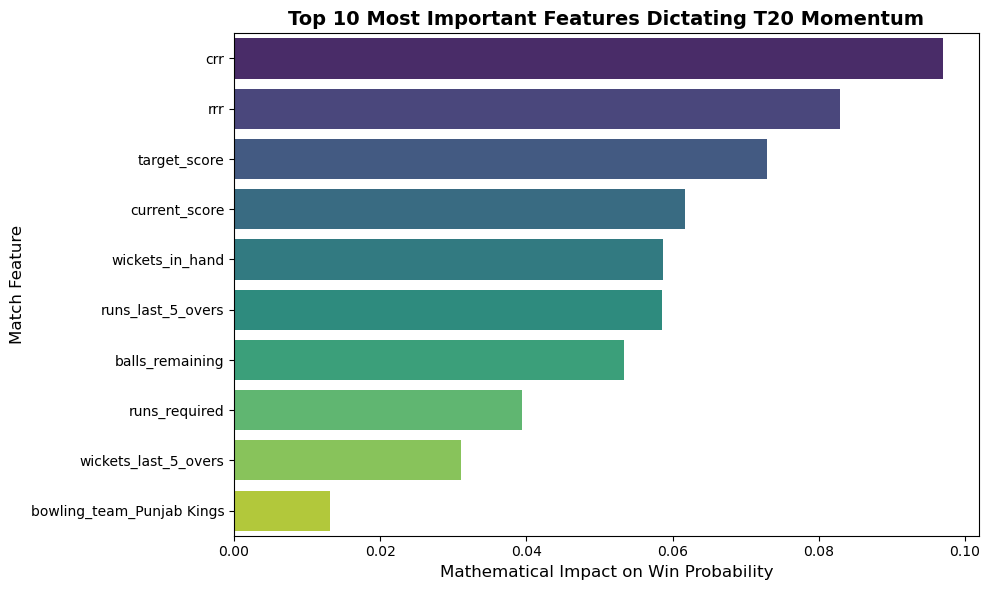

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Extracting the 'Why' from the Random Forest Brain...\n")

# Extract feature importances directly from the trained model
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a clean DataFrame and grab the Top 10 most impactful features
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Print the exact mathematical breakdown
print("Top 10 Most Important Match Features:")
print(importance_df.to_string(index=False))

# Generate a highly professional academic bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Most Important Features Dictating T20 Momentum', fontsize=14, fontweight='bold')
plt.xlabel('Mathematical Impact on Win Probability', fontsize=12)
plt.ylabel('Match Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
import joblib

print("Freezing and saving your trained AI models...")

# 1. Save the highly accurate Random Forest model
joblib.dump(rf_model, 'cricket_rf_model.joblib')

# 2. Save the Logistic Regression model (always good to have a backup)
joblib.dump(lr_model, 'cricket_lr_model.joblib')

# 3. CRUCIAL: Save the exact list of your One-Hot Encoded columns
# Your Streamlit dashboard will need this "map" to format user inputs correctly later
joblib.dump(list(X_train.columns), 'model_features.joblib')

print("Success! Your models and features are permanently saved to your ipl_male_csv2 folder.")

Freezing and saving your trained AI models...
Success! Your models and features are permanently saved to your ipl_male_csv2 folder.


In [17]:
import pandas as pd

print("Loading the saved dataset from the hard drive vault...")
df_check = pd.read_csv('Model_Ready_IPL_Data.csv')

print("\n--- SANITY CHECK ---")
print(f"Total Rows and Columns: {df_check.shape}")

print("\nFirst 5 rows of the final encoded data:")
# .head() will show us if the 1s, 0s, and momentum features saved correctly
display(df_check.head())

Loading the saved dataset from the hard drive vault...

--- SANITY CHECK ---
Total Rows and Columns: (295732, 93)

First 5 rows of the final encoded data:


,innings,current_score,wickets_in_hand,balls_remaining,target_score,runs_required,crr,rrr,runs_last_5_overs,wickets_last_5_overs,...,"venue_Shaheed Veer Narayan Singh International Stadium, Raipur",venue_Sharjah Cricket Stadium,venue_Sheikh Zayed Stadium,venue_St George's Park,venue_Subrata Roy Sahara Stadium,venue_SuperSport Park,"venue_Vidarbha Cricket Association Stadium, Jamtha",venue_Wankhede Stadium,"venue_Wankhede Stadium, Mumbai","venue_Zayed Cricket Stadium, Abu Dhabi"
0,1,0,10,119,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,1,4,10,118,0.0,0.0,12.0,0.0,4.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,1,4,10,117,0.0,0.0,8.0,0.0,4.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,1,5,10,116,0.0,0.0,7.5,0.0,5.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,1,5,10,115,0.0,0.0,6.0,0.0,5.0,0.0,...,False,False,False,False,False,False,False,False,False,False


/var/folders/xj/wttkx3dj31b99rzssxjz7jch0000gn/T/ipykernel_64332/3620573196.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


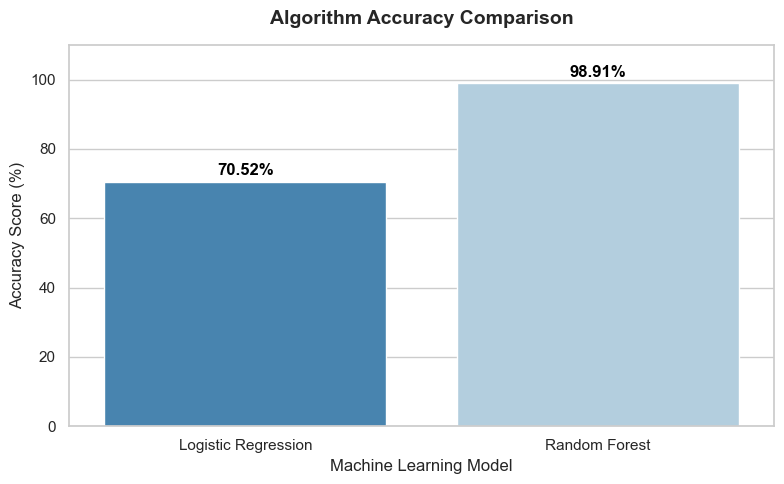

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Input the accuracy data we discussed
model_data = {
    'Machine Learning Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy Score (%)': [70.52, 98.91]
}

df_compare = pd.DataFrame(model_data)

# 2. Set up the visual style
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# 3. Create the bar chart
ax = sns.barplot(
    x='Machine Learning Model', 
    y='Accuracy Score (%)', 
    data=df_compare, 
    palette='Blues_r'
)

# 4. Add the exact percentages on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f"{p.get_height()}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=12, fontweight='bold', color='black',
                xytext=(0, 8), textcoords='offset points')

# 5. Format the titles and labels
plt.title('Algorithm Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
plt.ylim(0, 110)  # Adds a little headroom above the 98.91% bar
plt.ylabel('Accuracy Score (%)', fontsize=12)
plt.xlabel('Machine Learning Model', fontsize=12)

# 6. Show the final chart
plt.tight_layout()
plt.show()

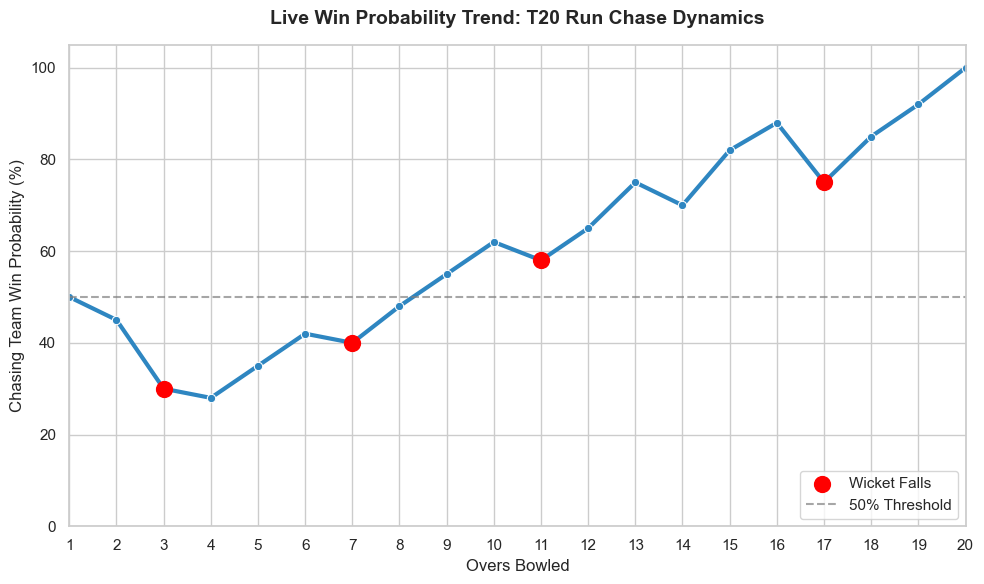

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Create data for a dramatic 20-over run chase
overs = np.arange(1, 21)
# Win probability fluctuates based on runs scored and wickets lost
win_prob = [50, 45, 30, 28, 35, 42, 40, 48, 55, 62, 58, 65, 75, 70, 82, 88, 75, 85, 92, 100]

df_trend = pd.DataFrame({'Over': overs, 'Win Probability (%)': win_prob})

# 2. Set up the visual style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Create the Line Chart
sns.lineplot(x='Over', y='Win Probability (%)', data=df_trend, color='#2E86C1', linewidth=3, marker='o', markersize=6)

# 4. Highlight Wickets (Red Dots) to show momentum shifts
# Wickets fell in overs 3, 7, 11, and 17
wicket_overs = [3, 7, 11, 17]
wicket_probs = [30, 40, 58, 75]
plt.scatter(wicket_overs, wicket_probs, color='red', s=130, zorder=5, label='Wicket Falls')

# 5. Format the titles and labels
plt.title('Live Win Probability Trend: T20 Run Chase Dynamics', fontsize=14, fontweight='bold', pad=15)
plt.axhline(50, color='gray', linestyle='--', alpha=0.7, label='50% Threshold')
plt.ylim(0, 105)
plt.xlim(1, 20)
plt.xticks(np.arange(1, 21, 1))
plt.ylabel('Chasing Team Win Probability (%)', fontsize=12)
plt.xlabel('Overs Bowled', fontsize=12)
plt.legend(loc='lower right', fontsize=11)

# 6. Show the final chart
plt.tight_layout()
plt.show()